# 変分オートエンコーダ (VAE)

この章では、変分オートエンコーダ（VAE: Variational Autoencoder）について説明する。
VAEは、現代的な生成モデルを理解する上でも重要なモデルである。

混合ガウスモデルの章で導入したKLダイバージェンスやELBOの概念はVAEの理解にも不可欠であるため、重複する部分もあるが重要なポイントを押さえながら説明していく。

## 生成モデルの考え方

何らかのデータを生成するモデルのことをざっくりと **生成モデル (Generative Model)** と呼ぶことにしよう。

我々が普段目にする画像や音声、テキストなどのデータは、現実世界の様々な要素が複雑に絡み合って生成されている。
その背景には確率分布(生成分布)を持っていて、その分布からサンプリングされたデータが我々の目に入っていると考えることができる。
もちろん、そうした生成分布を直接観測することはできないが、生成モデルはその生成分布を学習し、そこから新たなデータを生成することを目指している。

以下では、そんな生成モデルで実現したいタスクが「様々な犬の写真を生成する」であると仮定して説明を進める。

現実世界での犬の写真データは、非常に多様であり犬種や背景、個体ごとの違いなどがある。
しかし、犬の写真データをピクセル値として扱うと、それらは非常に高次元の空間で好き勝手バラバラに向いている訳ではない。
なぜなら、砂嵐のような画像は完全なランダム値であり、ピクセル値の空間では等方的に分布するだろうし、ラーメンの写真を大量に集めるとそれらはやはり、犬の写真が持つピクセル値の分布とは異なっているであろう。

ここで、もし、犬の写真データがもつ共通の特徴を捉えた低次元空間での潜在変数が存在すると仮定する。
もとのピクセル値が $D$ 次元のベクトルによって表されるとすると、その潜在変数は $d$ 次元 ($d \ll D$) のベクトルで表されるとする。

加えて、その潜在変数を"種"に、犬の写真データを生成してくれるモデル(例えばニューラルネットワーク)があるとする。
その潜在空間の中で $z_1, z_2, \ldots$ といった潜在変数をサンプリングし、それらの種をニューラルネットワークに入力することで、様々な犬の写真データ $x_1, x_2, \ldots$ を生成できることになる。

犬の部分を、より広い集合である「画像データ」に置き換えれば、生成モデルの役割は「現実世界に存在するような画像データを生成すること」にすることもできる。これが潜在変数を用いた生成モデルの基本的な考え方である。

実際にどのようにそのような潜在空間を見つけていくのか、また、生成モデルをどのように学習していくのかが肝になるが、この章ではVAEに注目してデータ生成の流れを説明しよう。

## VAEによるデータ生成の流れ

:::{margin}
オートエンコーダと呼ばれるモデルは、ニューラルネットワークを用いてデータの圧縮と再構成を行うモデルである。
オートエンコーダで活性化関数を恒等関数にし、損失関数を二乗誤差に取ると、主成分分析（PCA）と同等の動作をすることが知られている。
:::
変分オートエンコーダは、オートエンコーダの一種として位置付けられることもあるが、オートエンコーダとは異なり、データの生成過程をモデル化することを目的とした生成モデルとして解釈するのが一般的である。

その際、潜在変数を導入し、データが潜在変数から生成されると仮定する。
VAEでは、潜在変数の分布を近似するために変分推論を使用し、データの生成過程を学習していく。

VAEによるデータ生成の基本的な流れは以下の通りである。

1. 潜在変数のサンプリング: 潜在変数 $z$ を事前分布 $p(z)$ (通常、正規分布)からサンプリングする。
2. 観測変数の生成: 潜在変数 $z$ から観測変数 $x$ を生成するために、条件付き分布 $p_\theta(x|z)$ (例: ニューラルネットワークの出力+正規分布)を用いる。


```{image} pic/VAE_gen_sketch.png
:width: 500px
:align: center

```


単一の潜在変数ではなく、その確率分布を考えることで、より多様なデータ生成が可能になる。
また、ニューラルネットワークの出力値は入力値に対して確定的な値であるが、VAEではニューラルネットワークの出力を平均値とし、分散を持たせることで、同じ潜在変数からでも異なる観測変数が生成されるようにしているとも理解できる。

$$
\begin{align*}
p_{\theta}(x|z) = \mathcal{N}\left(x; \hat{x}(z; \theta), I\right)
\end{align*}
$$

出力したいデータの種類によっては、分布の形状を変えることもある。例えば観測変数が0から1の範囲に収まるようなデータであれば、ベルヌーイ分布を用いることもある。

## 生成モデルの学習

では、VAEの生成モデルをどのように学習していくのか。

VAEでは、観測変数 $x$ のモデル分布 $p_{\theta}(x)$ を与えられたデータセット $\{x^{(i)}\}_{i=1}^{N}$に対して、モデルを特徴づけるパラメータ $\theta$ を調整することで、データセットの分布をよく表現するようにしてやる。
(モデルが単なる正規分布であれば、$\theta$は平均や分散だし、ニューラルネットワークであれば、$\theta$はその重みやバイアスになる。)
下に、模式図を示す。


```{image} pic/likelihood.png
:width: 500px
:align: center

```

これは、以下の対数尤度を最大化することと同値である。

$$
\begin{align}
\mathcal{L}(\theta) & = \sum_{i=1}^{N} \log p_{\theta}(x^{(i)}) \\
p_{\theta}(x^{(i)}) & \equiv p(x^{(i)}|\theta)
\end{align}
$$ (eq:vae_loglikelihood)

$p_{\theta}(x^{(i)})$は、正規分布のような単純な分布であれば解析的に計算できるが、VAEのように潜在変数を導入した生成モデルでは、以下のように潜在変数 $z$ に関して積分を行う必要がある。

$$
\begin{align}
p_{\theta}(x^{(i)}) = \int p_{\theta}(x^{(i)}|z) p(z) dz
\end{align}
$$ (eq:vae_marginal_likelihood)

この積分についてもやはり解析的に計算することは難しい。$z$のサンプルを用いてモンテカルロ積分を行うこともできるが、計算コストが高くなってしまう。

そこで、VAEでは変分推論の考え方を用いて、潜在変数 $z$ の事後分布 $p_{\theta}(z|x)$ を近似するための近似分布 $q(z)$ を導入する。


まず、具体的な確率分布がどう与えられるかとは関係なく、対数尤度を以下のように変形できることを思い出そう。

$$
\begin{align}
\log p_{\theta}(x) &= \int q(z) \log p_{\theta}(x) dz \\
&= \int q(z) \log \frac{p_{\theta}(x, z)}{p_{\theta}(z|x)} \frac{q(z)}{q(z)} dz \\
&= \int q(z) \log \frac{p_{\theta}(x, z)}{q(z)} dz + \int q(z) \log \frac{q(z)}{p_{\theta}(z|x)} dz \\
&= {\color{red}{ \int q(z) \log \frac{p_{\theta}(x, z)}{q(z)} dz }}+ \colorbox{yellow}{ $D_{KL}(q(z) || p_{\theta}(z|x))$}　\\
& \geq {\color{red}{ \int q(z) \log \frac{p_{\theta}(x, z)}{q(z)} dz }}
\end{align}
$$ (eq:vae_elbo_decomposition)

ここで、赤字で示した部分を **ELBO (Evidence Lower Bound)** と呼ぶ。
また、黄色で示した部分はKLダイバージェンスであり、常に非負であることから、**ELBOは対数尤度の下限** であることが分かる。
したがって、左辺の対数尤度を直接手に負えないのであれば、ELBOを最大化することで、対数尤度の下限を最大化することができる、というのがELBOを用いる動機・利点である。


仮にこの $q(z)$ をパラメータ $\phi$ で特徴づけるとしよう(正規分布の場合は、平均や分散に相当する)。
とくにVAEでは、観測変数 $x$ に依存するように $q_{\phi}(z|x)$ を定義するので、以降は $q(z)$ を $q_{\phi}(z|x)$ と書くことにする。

すると、ELBOは以下のように書ける。

$$
\begin{align}
\mathrm{ELBO}(\theta, \phi; x) &= \int q_{\phi}(z|x) \log \frac{p_{\theta}(x, z)}{q_{\phi}(z|x)} dz 
\end{align}
$$ (eq:vae_elbo)   

少々くどいが、$\theta$はDecoderのパラメータ、$\phi$はEncoderのパラメータであることを思い出しておこう。

ここで、ELBOの最大化が対数尤度の下限を最大化することに繋がることもじっくりと確認しておこう。
よくよく考えると上で出てきた確率分布 $q(z)$ (いまは $q_{\phi}(z|x)$)は、規格化された確率分布であり左辺とはなんの関係もなかったはずである。なので、パラメータ $\phi$を変化させても、左辺の対数尤度にはなんの影響も与えないはずである。しかし、右辺のELBOは、$\phi, \theta$の変化を通して影響を受ける。

$\phi$に着目する限りは左辺(２つの項の総和)は変わらないのだから、ELBOを最大化することは、KLダイバージェンスを最小化する($q_{\phi}(z)$を $p_{\theta}(z|x)$に近づける)ことに他ならない。

計算の難しい事後分布 $p_{\theta}(z|x)$ を直接扱うのではなく、近似分布 $q_{\phi}(z|x)$ を導入し、ELBOを最大化することで、事後分布を近似するというのがVAEの基本的な考え方で、これは変分推論の枠組みの一種であることから、variationalという名前が付けられている。




## 近似分布のパラメータの確率分布

上の式では、あるタイミングでこっそりと、データの足に対する添字を落としている。
実際には、データセット $\{x^{(i)}\}_{i=1}^{N}$ の各データ点 $x^{(i)}$ に対して、近似分布 $q_{\phi}(z|x^{(i)})$ のパラメータ $\phi$ は異なる値を取ることになる。
したがって、ELBOも各データ点ごとに異なる値を取ることになる。

しかしながら、大きなデータセットに対しては、各データ点ごとに異なるパラメータを持つのは非効率・非現実的である。
そこで、近似分布のパラメータ $\phi$ 自体もニューラルネットワークを用いて入力データ $x^{(i)}$ から計算するようにする。

これは、観測変数 $x$ から潜在変数 $z$ へのマッピングを学習するエンコーダ (Encoder)を導入することを意味している。
今度はencoderのパラメータを $\phi$ と表記しよう。すると、近似分布 $q(z)$ は、ニューラルネットワークの出力 $\phi(x^{(i)}; \phi)$ によって与えられることになる。
図にすると以下のようになる。


```{image} pic/encoder_vae.png
:width: 500px
:align: center

```


encoderによって生成される近似分布が正規分布であるとすると、非対角成分を持つ分散行列 $\Sigma$ を生成することも考えられなくはないが、計算コストの観点から、$\Sigma$を対角行列とする(独立な各次元の分散を生成させる)のが一般的と思われる。


## ELBOの計算

ELBOを最大化することで、対数尤度の下限を最大化できることは分かったが、実際にELBOをどのように計算するのか。少し式を変形してみよう。

$$
\begin{align}
\mathrm{ELBO}(\theta, \phi; x) &= \int q_{\phi}(z|x) \log \frac{p_{\theta}(x, z)}{q_{\phi}(z|x)} dz \nonumber \\
& = \int q_{\phi}(z|x) \log p_{\theta}(x|z) dz - D_{KL}(q_{\phi}(z|x) || p(z)) 
\end{align}
$$

最後の表式の第１項は、潜在変数 $z$ に関する期待値であり、第２項はKLダイバージェンスである。
第１項は、$z$を $q_{\phi}(z|x)$ からサンプリングすることで近似的に計算できる。
VAEでは大胆にも、サンプルサイズを1にして、以下のように近似することが多い。

$$
\begin{align}
\int q_{\phi}(z|x) \log p_{\theta}(x|z) dz \approx \log p_{\theta}(x|z^{(l)}) \quad \mathrm{where} \quad z^{(l)} \sim q_{\phi}(z|x)
\end{align}
$$

つまり、前者の項は、サンプルされた潜在変数をデコーダに入力したときの観測変数の対数尤度を計算すれば良いことになる。
デコーダの出力 $\hat{x}$と、入力 $x$ の差を損失関数として用いると、これは**再構成誤差** と呼ぶこともできる。

第２項のKLダイバージェンスは、$q_{\phi}(z|x)$ と $p(z)$ の具体的な形状によっては解析的に計算できる。
例えば、$q_{\phi}(z|x)$ と $p(z)$ がともに多変量正規分布であれば、KLダイバージェンスは以下のように計算できる。

$$
\begin{align}
q_{\phi}(z|x) & = \mathcal{N}(z; \mu_{\phi}(x), \mathrm{diag}(\sigma^2_{\phi}(x))) \\
p(z) & = \mathcal{N}(z; 0, I) \\
D_{KL}(q_{\phi}(z|x) || p(z)) & = \frac{1}{2} \sum_{j=1}^{d} \left( \sigma_{j}^{2} + \mu_{j}^{2} - 1 - \log \sigma_{j}^{2} \right)
\end{align}
$$

ここで $d$ は潜在変数の次元数、$\mu_{j}$と$\sigma_{j}$はそれぞれ$j$番目の次元に対応する平均と標準偏差 (エンコーダによる出力) である。

## ELBOの最大化と変数変換トリック

ここまでで、VAEの基本的な構成要素が出揃ってきた。


```{image} pic/VAE_sketch.png
:width: 750px
:align: center

```


ELBOを最大化するためには、ELBOの勾配を計算し、その勾配に基づいてEncoder/Decoderのパラメータ $\theta$ と $\phi$ を更新していく必要がある。

しかしながら、ELBOの第１項は、近似分布 $q_{\phi}(z|x)$ からサンプリングした潜在変数 $z$ に依存しているため、直接的に $\phi$ に関する勾配を計算することが難しい。
そこで、**変数変換トリック (Reparameterization Trick)** と呼ばれる手法を用いることで、勾配の計算を可能にする。

具体的には、潜在変数 $z$ を以下のように変数変換する。

$$
\begin{align}
z = \mu_{\phi}(x) + \sigma_{\phi}(x) \odot \epsilon \quad \mathrm{where} \quad \epsilon \sim \mathcal{N}(0, I)
\end{align}
$$

ここで、$\odot$ は要素ごとの積を表す。
つまり、$z$自体をサンプリングするのではなく、標準正規分布からサンプリングした $\epsilon$ を用いて $z$ を生成するようにする。

これにより計算グラフが $\phi$ に対して連続的になるため、勾配を計算できるようになる。

## MNISTデータセットでのVAEの実装例

Epoch 1, Loss: 41.18
Epoch 2, Loss: 33.83
Epoch 3, Loss: 32.58
Epoch 4, Loss: 32.01
Epoch 5, Loss: 31.66
Epoch 6, Loss: 31.39
Epoch 7, Loss: 31.22
Epoch 8, Loss: 31.03
Epoch 9, Loss: 30.91
Epoch 10, Loss: 30.79
Epoch 11, Loss: 30.68
Epoch 12, Loss: 30.60
Epoch 13, Loss: 30.48
Epoch 14, Loss: 30.43
Epoch 15, Loss: 30.35


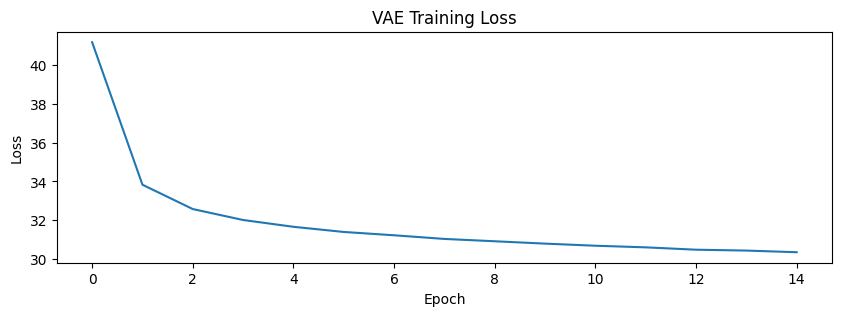

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

batch_size = 32
latent_dim = 20
hidden_dim = 200

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

class VAE(nn.Module):
    def __init__(self, latent_dim=20, hidden_dim=200):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(28*28, hidden_dim),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 28*28),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

def vae_loss(x, x_recon, mu, logvar):
    # Reconstruction loss (binary cross entropy)
    # recon_loss = nn.functional.binary_cross_entropy(
    #     x_recon, x, reduction="sum"
    # )
    recon_loss = nn.functional.mse_loss(
        x_recon, x, reduction="sum"
    )
    # KL divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE(latent_dim=20).to(device)
optimizer = optim.Adam(model.parameters())

epochs = 15
loss_history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, _ in train_loader:
        x = x.view(-1, 28*28).to(device)

        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss = vae_loss(x, x_recon, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_dataset)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.2f}")

# 学習曲線のプロット
fig = plt.figure(figsize=(10, 3))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE Training Loss')
plt.show()

学習済みのVAEで、手書き数字画像を生成してみる...

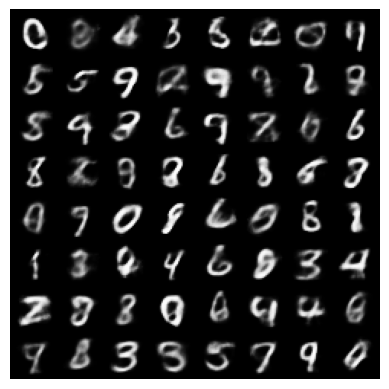

In [18]:
with torch.no_grad():
    z = torch.randn(64, 20).to(device)
    samples = model.decode(z).view(-1, 1, 28, 28)

# 可視化
from torchvision.utils import make_grid
grid_img = make_grid(samples.cpu(), nrow=8)
plt.imshow(grid_img.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.show() 